# Cam Shapes to Force

Takes previously generated transmission and storage cam point clouds and
derives the cable-tension-vs-stroke curve implied by their shapes, as an
exploratory cross-check of the force calculations in
[class_cam_generation.py](../class_cam_generation.py) (specifically
`CamGeneration.get_moment_arms`/`calc_forces`).

For each cam profile the notebook computes an "effective" cable-direction
moment arm at every angle (the maximum cable-direction projection among
nearby profile points), then compares cable tension computed three ways: from
raw cam radii, from the effective radii, and from a spatially accurate model
that accounts for cable unwrapping and anchor geometry.

**Inputs:** transmission cam points (`data/si2st_augmented_points.txt` or
`data/st2si_63.txt`) and storage cam points (`data/outer_63.txt`), selected
via the `profile` variable.
**Outputs:** diagnostic plots of tension vs. stroke, and a `.mat` file under
`results/force_plots/` for further analysis in MATLAB.

In [ ]:
import numpy as np
from scipy.io import savemat
import matplotlib.pyplot as plt

In [ ]:
def to_polar(points):
        """
        Convert the given Cartesian points to polar coordinates.

        Args:
            points (ndarray): Array of Cartesian points.

        Returns:
            ndarray: Array of radii.
            ndarray: Array of angles.
        """
        # Calculate radii and angles of the points.
        radii = np.linalg.norm(points, axis=1)
        angles = np.arctan2(points[:, 1], points[:, 0])
        for ind, angle in enumerate(angles):
            if angle < 0:
                angles[ind] += 2*np.pi
        return radii, angles

def to_cartesian(radii, angles):
        """
        Convert the given polar coordinates to Cartesian points.

        Args:
            radii (ndarray): Array of radii.
            angles (ndarray): Array of angles.

        Returns:
            ndarray: Array of Cartesian points.
        """
        x = radii * np.cos(angles)
        y = radii * np.sin(angles)
        return np.column_stack((x, y))

def rotate_cam(radii, offset_ind = 180):
        """Rotate an array of cam radii by offset_ind indices (leftward
        cyclic shift) to account for where the elastic band leaves the cam
        surface relative to where the cable leaves it.
        """
        cam_original = radii.copy()
        outer_1 = radii[: offset_ind]
        outer_2 = radii[offset_ind :]
        cam_rotated = np.concatenate((outer_2, outer_1))
        return cam_rotated, cam_original

def effective_radius(xy):
    """
    For each point on a cam profile, find the maximum cable-direction
    projection among points within +/-90 degrees of it (the "effective"
    moment arm). This is the exploratory precursor to
    class_cam_generation.CamGeneration.get_moment_arms, extended to also
    return the full 2D coordinates and source index of each effective point.

    Parameters:
    xy: cam profile points in Cartesian coordinates, ordered by angle (one
        point per degree, 360 points)

    Returns:
    r_effective: Cartesian (x, y) coordinates of the effective point chosen
        at each degree
    x_effective: x-projection (cable-direction moment arm) at each degree
    y_effective: y-projection of the effective point at each degree
    effective_ind_array: index into xy of the effective point chosen for
        each degree
    """
    [r, theta] = to_polar(xy)
    x_candidates = np.zeros(181) # Initialize effective radius candidates for each point
    y_candidates = np.zeros(181) # Initialize effective radius candidates for each point
    r_effective = np.zeros((len(r), 2)) # Initialize array to hold effective radii
    x_effective = np.zeros_like(r) # Initialize array to hold effective x-projections
    y_effective = np.zeros_like(r) # Initialize array to hold effective y-projections
    offset_deg_array = np.zeros(181, dtype=int) # Initialize array to hold offset degrees
    effective_ind_array = np.zeros(361, dtype=int) # Initialize array to hold effective indices

    # For each point on the cam, find the maximum projected distance of the points that are within ±90 degrees of the point
    for ang_ind in range(360): # the angle of the "nominal" point on the cam profile
        for offset_ind in range(181): # loop through 181 candidate points that are within ±90 degrees of the nominal point

            if ang_ind + offset_ind - 90 < 0: # Don't consider points before the cable anchoring point
                offset_deg = -ang_ind
            elif ang_ind + offset_ind - 90 >= 360: # Don't consider points over 360 degrees
                offset_deg = 360 - ang_ind
            else:
                offset_deg = offset_ind - 90

            # Calculate the projected distance for all candidate points
            x_candidates[offset_ind] = r[ang_ind + offset_deg] * np.cos(np.deg2rad(offset_deg))
            y_candidates[offset_ind] = r[ang_ind + offset_deg] * np.sin(np.deg2rad(offset_deg))
            offset_deg_array[offset_ind] = offset_deg

        # Get the index, radius, and x-projection of the point corresponding to the maximum projected distance
        max_index = np.argmax(x_candidates)
        max_offset_deg = offset_deg_array[max_index]
        effective_ind = ang_ind + max_offset_deg
        effective_ind_array[ang_ind] = effective_ind

        x_effective[ang_ind] = max(x_candidates)
        y_effective[ang_ind] = y_candidates[max_index]
        r_effective[ang_ind, :] = [x_effective[ang_ind], y_effective[ang_ind]]

    return r_effective, x_effective, y_effective, effective_ind_array

In [ ]:
# EDIT: choose profile to plot
# profile = 'si2st'
profile = 'st2si'

n_interp = 360
offset_ind = 180
sit_angle = 220
k = 100 # N/m
sit_ind = round(sit_angle * 360 / n_interp)

# Get cam point clouds in Cartesian coordinates and convert from mm to meters
if profile == 'si2st':
    trans_cam_xy = np.loadtxt('data/si2st_augmented_points.txt', delimiter='\t', ndmin=2, usecols=(0,1)) # mm
else:
    trans_cam_xy = np.loadtxt('data/st2si_63.txt', delimiter=',', ndmin=2, usecols=(0,1)) # mm
stor_cam_xy = np.loadtxt('data/outer_63.txt', delimiter=',', ndmin=2, usecols=(0,1)) # mm

trans_cam_xy = trans_cam_xy / 1000 # meters
stor_cam_xy = stor_cam_xy / 1000 # meters

# Rotate storage cam values to account for where relative difference in where cables leave cam surfaces.
r_trans, theta_trans = to_polar(trans_cam_xy)
r_stor, theta_stor = to_polar(stor_cam_xy)
r_stor_rot, r_stor_orig = rotate_cam(r_stor, offset_ind)
stor_cam_xy_rot = to_cartesian(r_stor_rot, theta_stor)

# Check that cams in polar coordinates are correct
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.scatter(theta_trans, r_trans)
ax.grid(True)
ax.set_title('transmission cam (polar)')
plt.show()

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.scatter(theta_stor, r_stor_rot)
ax.grid(True)
ax.set_title('storage cam (polar)')
plt.show()

In [ ]:
x_stor = np.cumsum(r_stor_rot * 2*np.pi / n_interp)
f_elastic = k * x_stor
f_trans =  f_elastic * r_stor_rot / r_trans
x_trans = np.cumsum(r_trans * 2*np.pi / n_interp)

# Define linear stroke using full curve length of each cam
x_stor_lin = np.linspace(0, x_stor[-1], len(x_stor))
x_trans_lin = np.linspace(0, x_trans[-1], len(x_trans))

# Define alternative linear stroke using stroke length at sit angle
x_stor_lin_alt = np.linspace(0, x_stor[sit_ind], len(x_stor))

print('==== STORAGE CAM (ROTATED) ====')
r_eff_stor, x_eff_stor, y_eff_stor, effective_ind_stor = effective_radius(stor_cam_xy_rot)
print('==== TRANSMISSION CAM ====')
r_eff_trans, x_eff_trans, y_eff_trans, effective_ind_trans = effective_radius(trans_cam_xy)

# Calculate tension in transmission cable using effective radius values
f_elastic_eff = k * x_stor
f_trans_eff =  f_elastic_eff * x_eff_stor / x_eff_trans # using the projected x values for the effective radius ratio, rather than the raw radius values

# Calculate tension in transmission cable using linear x values
f_elastic_lin = k * x_stor_lin
f_trans_lin =  f_elastic_lin * x_eff_stor / x_eff_trans # using the projected x values for the effective radius ratio, rather than the raw radius values

# Calculate cable displacement using spatially accurate values
l_cable = 0.245 # meters, storage cable length
r_anchor = [-0.315, 0.0187] # meters, arbitrary anchor point location relative to cam center
l_spring_rest = 0.10 # meters, spring rest length
stroke_stor = np.zeros(361)
for ang_ind in range(361):
    vec_free = r_eff_stor[ang_ind, :] - r_anchor
    l_unwrapped = l_cable - x_stor[effective_ind_stor[ang_ind]]
    l_spring = np.linalg.norm(vec_free) - l_unwrapped
    stroke_stor[ang_ind] = l_spring - l_spring_rest

# Calculate tension in transmission cable using spatially accurate values
f_elastic_spatial = k * stroke_stor
f_trans_spatial = f_elastic_spatial * x_eff_stor / x_eff_trans

# Check effective lengths with plots
plt.figure()
plt.scatter(range(361), x_eff_stor)
plt.xlabel('Cam point index')
plt.ylabel('Effective storage cam x-projection (m)')
plt.title('Effective storage cam x-projection vs. cam point index')

plt.figure()
plt.scatter(range(361), r_stor_rot)
plt.xlabel('Cam point index')
plt.ylabel('Raw storage cam radius (m)')
plt.title('Raw storage cam radius vs. cam point index')

plt.figure()
plt.scatter(range(361), x_eff_trans)
plt.xlabel('Cam point index')
plt.ylabel('Effective transmission cam x-projection (m)')
plt.title('Effective transmission cam x-projection vs. cam point index')

plt.figure()
plt.scatter(range(361), r_trans)
plt.xlabel('Cam point index')
plt.ylabel('Raw transmission cam radius (m)')
plt.title('Raw transmission cam radius vs. cam point index')

plt.figure()
plt.scatter(range(361), x_stor)
plt.xlabel('Cam point index')
plt.ylabel('Raw storage cable displacement (m)')
plt.title('Raw storage cable displacement vs. cam point index')

plt.figure()
plt.scatter(range(361), stroke_stor)
plt.xlabel('Cam point index')
plt.ylabel('Spatial spring displacement (m)')
plt.title('Spatial spring displacement vs. cam point index')

plt.figure()
plt.scatter(range(361), x_stor_lin)
plt.xlabel('Cam point index')
plt.ylabel('Linear storage cable displacement (m)')
plt.title('Linear storage cable displacement vs. cam point index')

plt.figure()
plt.scatter(range(361), x_trans)
plt.xlabel('Cam point index')
plt.ylabel('Raw transmission cable displacement (m)')
plt.title('Raw transmission cable displacement vs. cam point index')

plt.figure()
plt.scatter(range(361), x_trans_lin)
plt.xlabel('Cam point index')
plt.ylabel('Linear transmission cable displacement (m)')
plt.title('Linear transmission cable displacement vs. cam point index')

Text(0.5, 1.0, 'Effective spring force vs. cam point index')

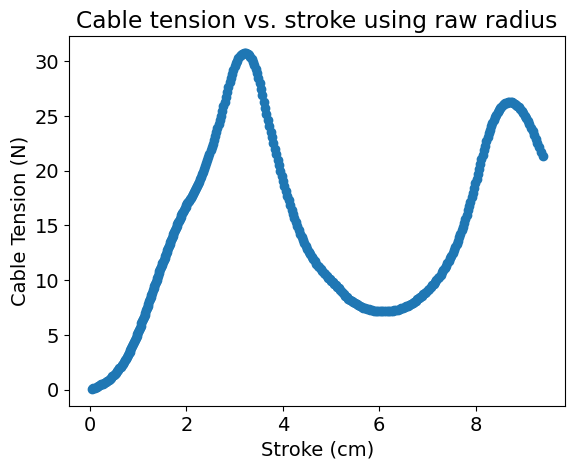

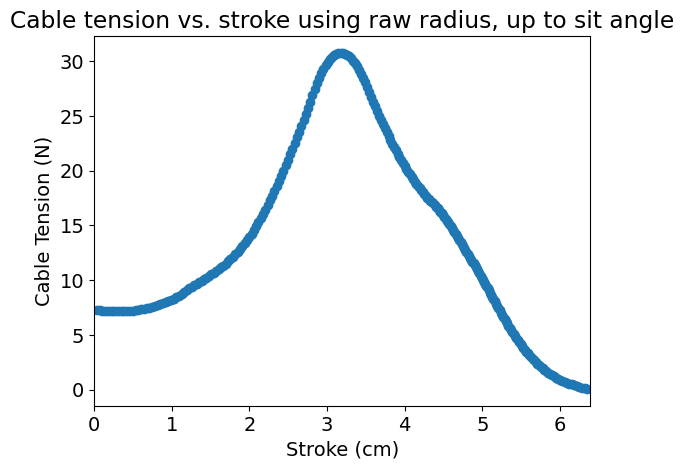

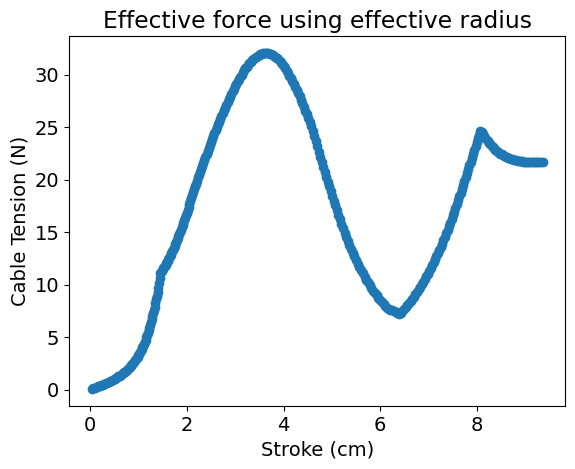

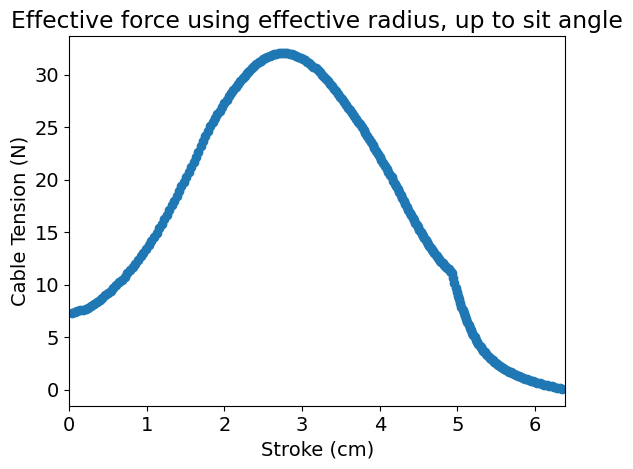

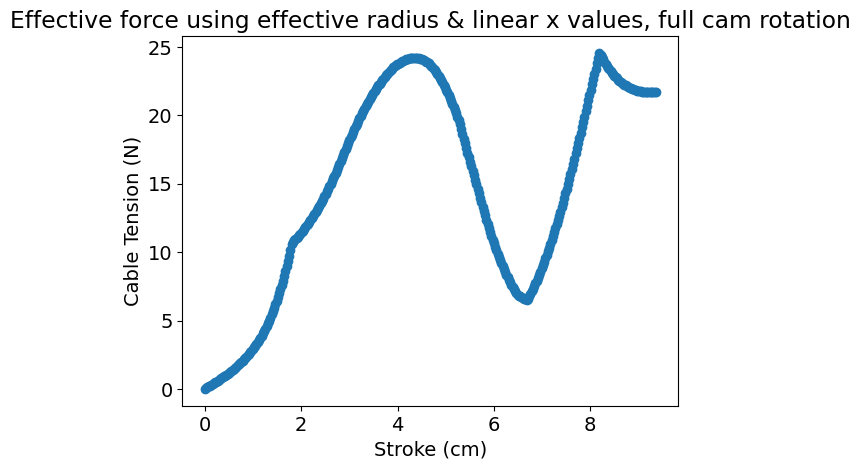

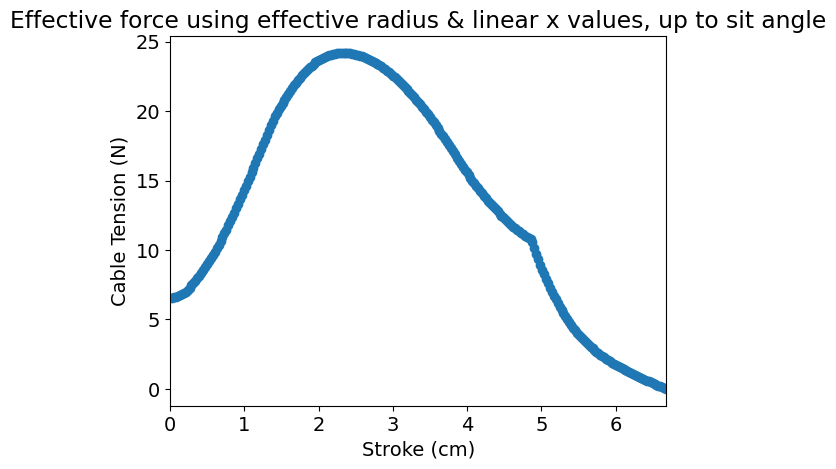

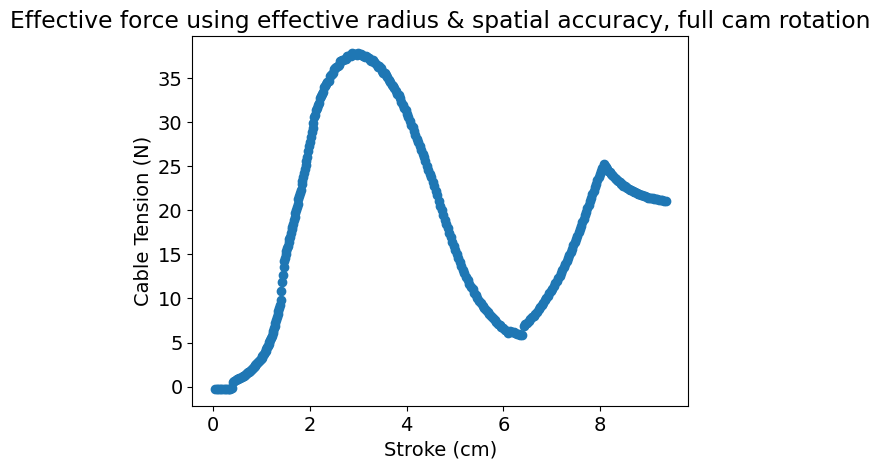

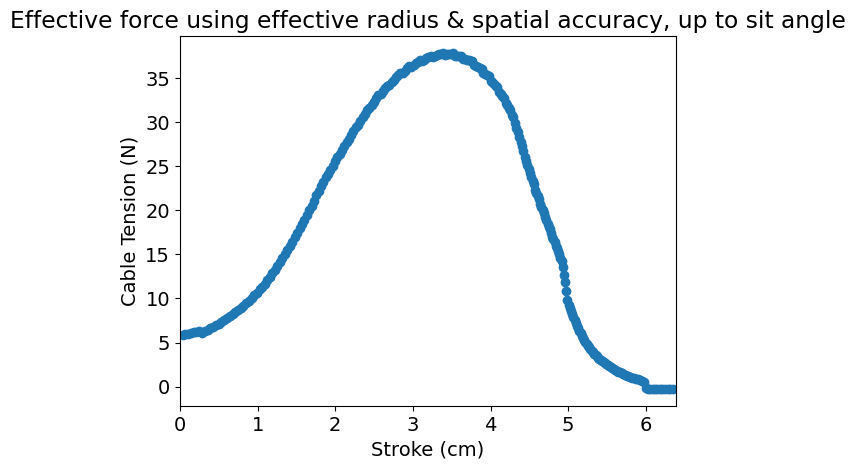

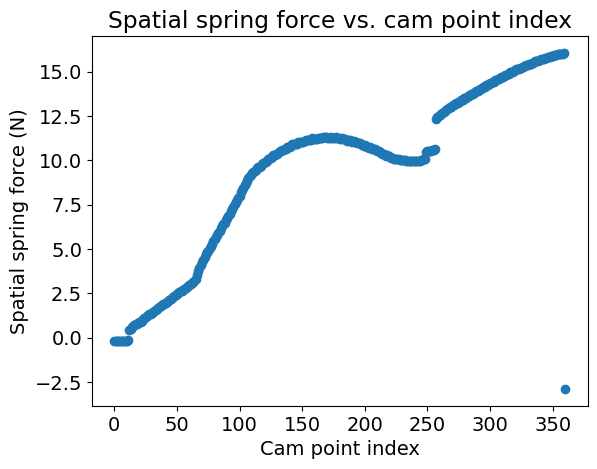

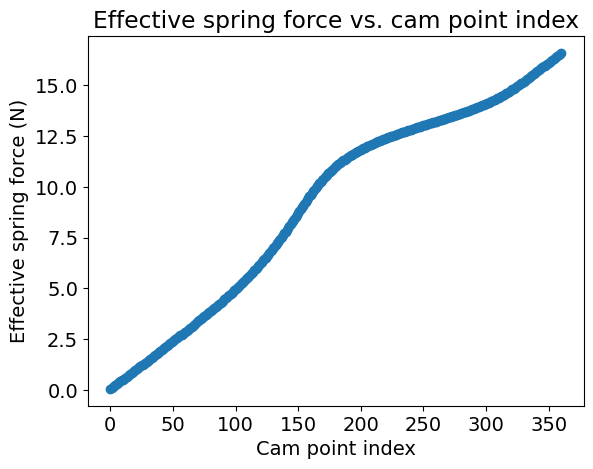

In [29]:
# Plot data

# Full cam rotation
plt.figure()
plt.scatter(x_trans * 100, f_trans)
plt.xlabel('Stroke (cm)')
plt.ylabel('Cable Tension (N)')
plt.title('Cable tension vs. stroke using raw radius')

# Rotation up to sit angle
plt.figure()
x_sub = x_trans[:sit_ind]
x_sub = x_trans[sit_ind] - x_sub
plt.scatter(x_sub * 100, f_trans[:sit_ind])
plt.xlabel('Stroke (cm)')
plt.ylabel('Cable Tension (N)')
plt.xlim(0, x_trans[sit_ind] * 100)
# plt.ylim((0, 70))
plt.title('Cable tension vs. stroke using raw radius, up to sit angle')

# USING EFFECTIVE RADII:
# Full cam rotation
plt.figure()
plt.scatter(x_trans * 100, f_trans_eff)
plt.xlabel('Stroke (cm)')
plt.ylabel('Cable Tension (N)')
plt.title('Effective force using effective radius')

# Rotation up to sit angle
plt.figure()
x_sub = x_trans[:sit_ind]
x_sub = x_trans[sit_ind] - x_sub
plt.scatter(x_sub * 100, f_trans_eff[:sit_ind])
plt.xlabel('Stroke (cm)')
plt.ylabel('Cable Tension (N)')
plt.xlim(0, x_trans[sit_ind] * 100)
plt.title('Effective force using effective radius, up to sit angle')

# USING LINEAR X VALUES:
# Full cam rotation
plt.figure()
plt.scatter(x_trans_lin * 100, f_trans_lin)
plt.xlabel('Stroke (cm)')
plt.ylabel('Cable Tension (N)')
plt.title('Effective force using effective radius & linear x values, full cam rotation') 

# Rotation up to sit angle
plt.figure()
x_sub = x_trans_lin[:sit_ind]
x_sub = x_trans_lin[sit_ind] - x_sub
plt.scatter(x_sub * 100, f_trans_lin[:sit_ind])
plt.xlabel('Stroke (cm)')
plt.ylabel('Cable Tension (N)')
plt.xlim(0, x_trans_lin[sit_ind] * 100)
plt.title('Effective force using effective radius & linear x values, up to sit angle')

# USING SPATIALLY ACCURATE FORCE CALCULATIONS:
# Full cam rotation
plt.figure()
plt.scatter(x_trans * 100, f_trans_spatial)
plt.xlabel('Stroke (cm)')
plt.ylabel('Cable Tension (N)')
plt.title('Effective force using effective radius & spatial accuracy, full cam rotation') 

# Rotation up to sit angle
plt.figure()
x_sub = x_trans[:sit_ind]
x_sub = x_trans[sit_ind] - x_sub
plt.scatter(x_sub * 100, f_trans_spatial[:sit_ind])
plt.xlabel('Stroke (cm)')
plt.ylabel('Cable Tension (N)')
plt.xlim(0, x_trans[sit_ind] * 100)
plt.title('Effective force using effective radius & spatial accuracy, up to sit angle')

# SPRING INVESTIGATION PLOTS:
plt.figure()
plt.scatter(range(361), f_elastic_spatial)
plt.xlabel('Cam point index')
plt.ylabel('Spatial spring force (N)')
plt.title('Spatial spring force vs. cam point index')

plt.figure()
plt.scatter(range(361), f_elastic_eff)
plt.xlabel('Cam point index')
plt.ylabel('Effective spring force (N)')
plt.title('Effective spring force vs. cam point index')


In [ ]:
# Export data  for analysis and visualization in MATLAB
percent_cam = np.linspace(0, 100, sit_ind)
save_dict = {'F': f_trans_eff[:sit_ind],
             'x': x_trans[:sit_ind],
             'pct': percent_cam}
if profile == 'si2st':
    savemat('results/force_plots/si2st_force_63.mat', save_dict)
else:
    savemat('results/force_plots/st2si_force_63.mat', save_dict)